### CC-PULPO Case Study: Ammonia Production
This notebook showcases the application of CC-PULPO and the broader uncertainty framework to an ammonia production case study. Here, two epistemic uncertainty iterations are presented.

In [ ]:
# Import helpers to keep main script clean
import importlib
import a0_uncertainty_utils as unc_utils
import a0_uncertainty_plots as unc_plots

# Reload modules if they've been modified
importlib.reload(unc_utils)
importlib.reload(unc_plots)

import bw2data as bd
import bw2io as bi
from bw2io.package import BW2Package

from pulpo import pulpo 
from pulpo.utils.uncertainty import processor, plots

import numpy as np

#### LCI Implementation
First, create a project and import the **ecoinvent 3.10 (cutoff)** background LCI. Set your ecoinvent credentials as environment variables (_Windows: run Command Prompt as Administrator_):

```
setx ECOINVENT_USERNAME "your_username"
setx ECOINVENT_PASSWORD "your_password"
```

*Restart VS Code or your machine after setting these variables.*

In [2]:
PROJECT = "ammonia_last"
EI_NAME = "ecoinvent-3.10-cutoff"

#username = "your_username"  # Replace with actual username
#password = "your_password"  # Replace with actual password

# 1) Ensure project exists / is selected
bd.projects.set_current(PROJECT)

# 2) Import ecoinvent 3.10 cutoff if missing
if EI_NAME in bd.databases:
    print(f"Database '{EI_NAME}' already exists in project '{bd.projects.current}'.")
else:
    username, password = unc_utils.get_ecoinvent_credentials()
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",
        username=username,
        password=password,
    )
    print(f"Database '{EI_NAME}' installed successfully.")

Database 'ecoinvent-3.10-cutoff' already exists in project 'ammonia_last'.


Next, import the **ammonia foreground LCI** from the Excel spreadsheet.

In [3]:
# Path to your Excel file
excel_path = r"data/ammonia.xlsx"
FG_NAME = "ammonia"

if FG_NAME in bd.databases:
    print(f"Database '{FG_NAME}' already exists in project '{bd.projects.current}'.")
else:
    fg_db = bi.ExcelImporter(excel_path)
    fg_db.apply_strategies()
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])
    fg_db.match_database("ecoinvent-3.10-cutoff", fields=["name", "unit", "location", "reference product"])
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(biosphere_db, fields=["name", "categories", "location"])
    fg_db.statistics()
    fg_db.write_database()
    print(f"Database '{FG_NAME}' installed successfully.")

Database 'ammonia' already exists in project 'ammonia_last'.


#### LCIA Implementation (GWP Uncertainty)

This method has been obtained and adapted (introduction of -1 for biogenic carbon) from [Github](https://github.com/aleksandra-kim/gwp_uncertainties)

In [4]:
METHOD = ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
bd.projects.set_current(PROJECT)

if METHOD in bd.methods:
    print(f"Method '{METHOD}' already exists in the project.")
else:
    BW2Package.import_file("data/ipcc_uncertain.bw2package")
    print("IPCC 2013 GWP with uncertainty characterization factors added successfully.")

Method '('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')' already exists in the project.


### Case Study Definition

First, define some helper functions and specify missing project parameters.

In [5]:
# PROJECT; EI_NAME; FG_NAME; METHOD - Are all previously defined!
METHOD = str(METHOD)
DATABASES = [EI_NAME, FG_NAME]
DIRECTORY = "develop_tests"

def create_pulpo_worker(project, database, method, directory):
    """
    Create and initialize a PULPO optimizer instance.
    Returns: pulpo.PulpoOptimizer: Configured PULPO worker instance
    """
    # Create PulpoOptimizer instance
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    
    # Import LCI data
    pulpo_worker.get_lci_data()
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """Deterministic process retrieval to avoid order issues."""
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    # Try preferred locations first
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

Then, define the case study by specifying **demand**, **choices**, and **constraints**.

In [6]:
def define_ammonia_problem(pulpo_worker):
    """
    Define the ammonia production optimization problem with streamlined configuration.
    """
    # Choice definitions with capacities bound per-label
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
                "anaerobic digestion of animal manure",
            ],
            # 2030 EU-27 potentials from biomethane shares (38 bcm total; 24% ag, 21% sequential, 32% manure),
            # converted to raw biogas assuming ~57% CH₄ → 16.0 & 14.0 bcm & 21.3 bcm ≈ 1.60e10 & 1.40e10 & 2.13e10 m³/yr.
            "capacities": [1.60e10, 1.40e10, 2.13e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            # Methane pyrolysis capped to 10,000 t H2/yr (= 1.0e7 kg/yr); others left high for now.
            # "capacities": [3.0e8, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
            "capacities": [1e20, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}  # ~17.1 Mt/yr (EU)

    # Additional upper bounds (shared resources / feedstocks)
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1e20,     #1.875e9,  # 25% of ~7.5 Mt PP post-consumer waste ≈ 1.875 Mt/yr
        waste_ps: 1e20,     #3.25e8,   # 25% of ~1.3 Mt PS waste ≈ 0.325 Mt/yr
        ccs_process: 1e20,  #5.0e9,    # 5 MtCO2/yr (10% of EU-27 2030 NZIA target)
    }
    
    # Instantiate the optimization problem
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    return choices, demand

def solve_and_summarize(pulpo_worker, file_name='ammonia_results'):
    # Solve optimization problem
    pulpo_worker.solve(solver_name="gurobi")
    
    # Extract and summarize results
    result_data = pulpo_worker.extract_results()
    pulpo_worker.summarize_results(zeroes=True)
    
    return result_data

Solve the base case, without consideration of any uncertainties.

In [ ]:
# Create and initialize PULPO worker
print("1. Creating PULPO worker...")
pulpo_worker = create_pulpo_worker(PROJECT, DATABASES, METHOD, DIRECTORY)

# Define the optimization problem
print("2. Defining optimization problem...")
choices, demand = define_ammonia_problem(pulpo_worker)

# Solve the problem and get results
print("3. Solving optimization problem...")
result_data = solve_and_summarize(pulpo_worker, file_name='ammonia_test')

print(f"✅ Setup complete: {sum(len(c) for c in choices.values())} alternatives across {len(choices)} categories")

Creating PULPO worker...
Defining optimization problem...
Creating Instance
Instance created
Solving optimization problem...
Optimization problem solved using gurobi
status=ok, termination=optimal


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')",1,-2.817763e+10


## Choices Made

### biogas

...

,Value,Capacity
Metadata,,
"steam reforming, integrated (CCS) | ammonia | RER",1.710000e+10,1.000000e+20


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23523,"(ammonia, fc378c5b9e61e417e77ba0c166897da5_copy1)",CCS 200km pipeline 1000m deep | CO2 stored | RER,6.925536e+10,1.000000e+20


✅ Setup complete: 22 alternatives across 6 categories


### Ieration 0: Generic Uncertainty Treatment

In this iteration, no technology or availablity constraints are considered except for availability of waste feedstock. In a first step, the uncetainty data of the LCIs and LCIA method are analysed in order to proceed with the gap filling strategies.

In [8]:
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.,
    scaling_vector_strategy='constructed_demand',
    plot_results=False,
    plot_n_top_processes=19,
)

chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.475472e+01
Characterized inventory: (2648, 23569) 21677
Filtered characterized inventory: (2648, 23569) 21677
Deviation from LCA score: 0.0
inventory (2648, 23569) filtering resulted in 21677 of 21677 exchanges (100.0% of total impact) and took 0.006 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 82 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 16110 
Parameters without uncertainty information: 5510
In ammonia:
Parameters with uncertainty information: 16110 
Parameters without uncertainty information: 5510
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 57
Charactetization factors:
Parameters with uncertainty information: 31 
Parameters without uncertainty information: 51
Variable bounds:
Upper bound from choi

Uncertainty gaps are filled using triangular distributions based on statistical analysis of existing uncertainties. Background data uses interpolated bounds, foreground inventories use scaling factors (0.5-1.95 ... obtained from ecoinvent) with upward skew, and random noise adds artificial variance. Characterization factors use only existing uncertainties without gap filling.

In [ ]:
unc_strategies = [
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy( # Assuming that the Foreground uncertainties are similar to the background ones
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        upper_scaling_factor = 0.95, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        lower_scaling_factor = .5, # The same as from TriangularBoundInterpolationStrategy of EcoInvent
        noise_interval={'min':.1, 'max':.1}
    ),
    # This is set to very low scaling factors to reflect that we assume only off-the-shelf uncertainty in CFs based on literature
    processor.TriangluarBaseStrategy( # Based on Chen et al. 2021 10-20% variation in CFs
    uncertain_param_type='Cf',
    uncertain_param_subgroup=METHOD,
    upper_scaling_factor = 0.0001,
    lower_scaling_factor = 0.0001,
    noise_interval={'min':.00, 'max':.00},
    inverse_bounds_for_negative_values = False # This means that the skew is always towards zero, indepent if value is larger or smaller to zero
    )
    ]


'\n\n'

In [22]:
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)

Applying uncertainy strategy TriangularBoundInterpolationStrategy, for ecoinvent-3.10-cutoff in If
Computed spread statistics for 21620 uncertain parameters with defined uncertainty bounds.
upper spread statistics
geom: 0.4365 
mean: 1.6118
mode: 0    3.466758
Name: upper spread, dtype: float64
median: 0.8182
std: 7.1114
min: 0.0287
max: 786.9859


lower spread statistics
geom: 0.4365 
mean: 0.5634
mode: 0    0.776124
Name: lower spread, dtype: float64
median: 0.4116
std: 6.8874
min: 0.0279
max: 786.9859

After cleaning out outliers (z-score > 3), the spread statistics are:
upper spread statistics
geom: 0.4359 
mean: 1.5233
mode: 0    3.466758
Name: upper spread, dtype: float64
median: 0.8181
std: 1.6790
min: 0.0287
max: 21.4495


lower spread statistics
geom: 0.4359 
mean: 0.4838
mode: 0    0.776124
Name: lower spread, dtype: float64
median: 0.4115
std: 0.2618
min: 0.0279
max: 19.7686

The upper spread scaling factor for intervention flows is: 0.8180686905551984
The lower spread scali

Solve the multi-objective optimization problem using epsilon-constrained method on the lambda parameter.

In [30]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True)
lambda_epsilon_array = np.arange(0.5, 1.0, 0.02)
results_CC_it0 = pulpo_worker.solve_CC_problem(lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, solver_name="gurobi", plot_results=False)

No uncertainty data missing.
No uncertainty data missing.
Transforming If-ecoinvent-3.10-cutoff to normal distribution
21607 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
21607 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming If-ammonia to normal distribution
57 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Cf-('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain') to normal distribution
59 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming If-ammonia to normal distribution
57 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
Transforming Cf-('IPCC 2013', 'climate change', 'global warming potent

Visualize results

In [31]:
# Plot Pareto / CC results from results_CC
print('Generating Pareto front plot from CC results...')
plot_path = unc_plots.plot_pareto_from_results(results_CC_it0['results_CC'], results_dir=DIRECTORY, lambda_range=(0.5,0.98))
print(f'Pareto plot saved to: {plot_path}')

Generating Pareto front plot from CC results...


AttributeError: module 'a0_uncertainty_plots' has no attribute 'plot_pareto_from_results'

With a cutoff value of 0.05, we keep 2 process to an error of 73.65%
With a cutoff value of 0.05, we keep 2 process to an error of 78.72%
With a cutoff value of 0.05, we keep 2 process to an error of 78.72%
With a cutoff value of 0.05, we keep 2 process to an error of 84.37%
With a cutoff value of 0.05, we keep 2 process to an error of 84.37%
With a cutoff value of 0.05, we keep 2 process to an error of 90.73%
With a cutoff value of 0.05, we keep 2 process to an error of 90.73%
With a cutoff value of 0.05, we keep 3 process to an error of 81.51%
With a cutoff value of 0.05, we keep 3 process to an error of 81.51%
With a cutoff value of 0.05, we keep 3 process to an error of 88.43%
With a cutoff value of 0.05, we keep 3 process to an error of 88.43%
With a cutoff value of 0.05, we keep 3 process to an error of 96.53%
With a cutoff value of 0.05, we keep 3 process to an error of 96.53%
With a cutoff value of 0.05, we keep 3 process to an error of 106.09%
With a cutoff value of 0.05, we k

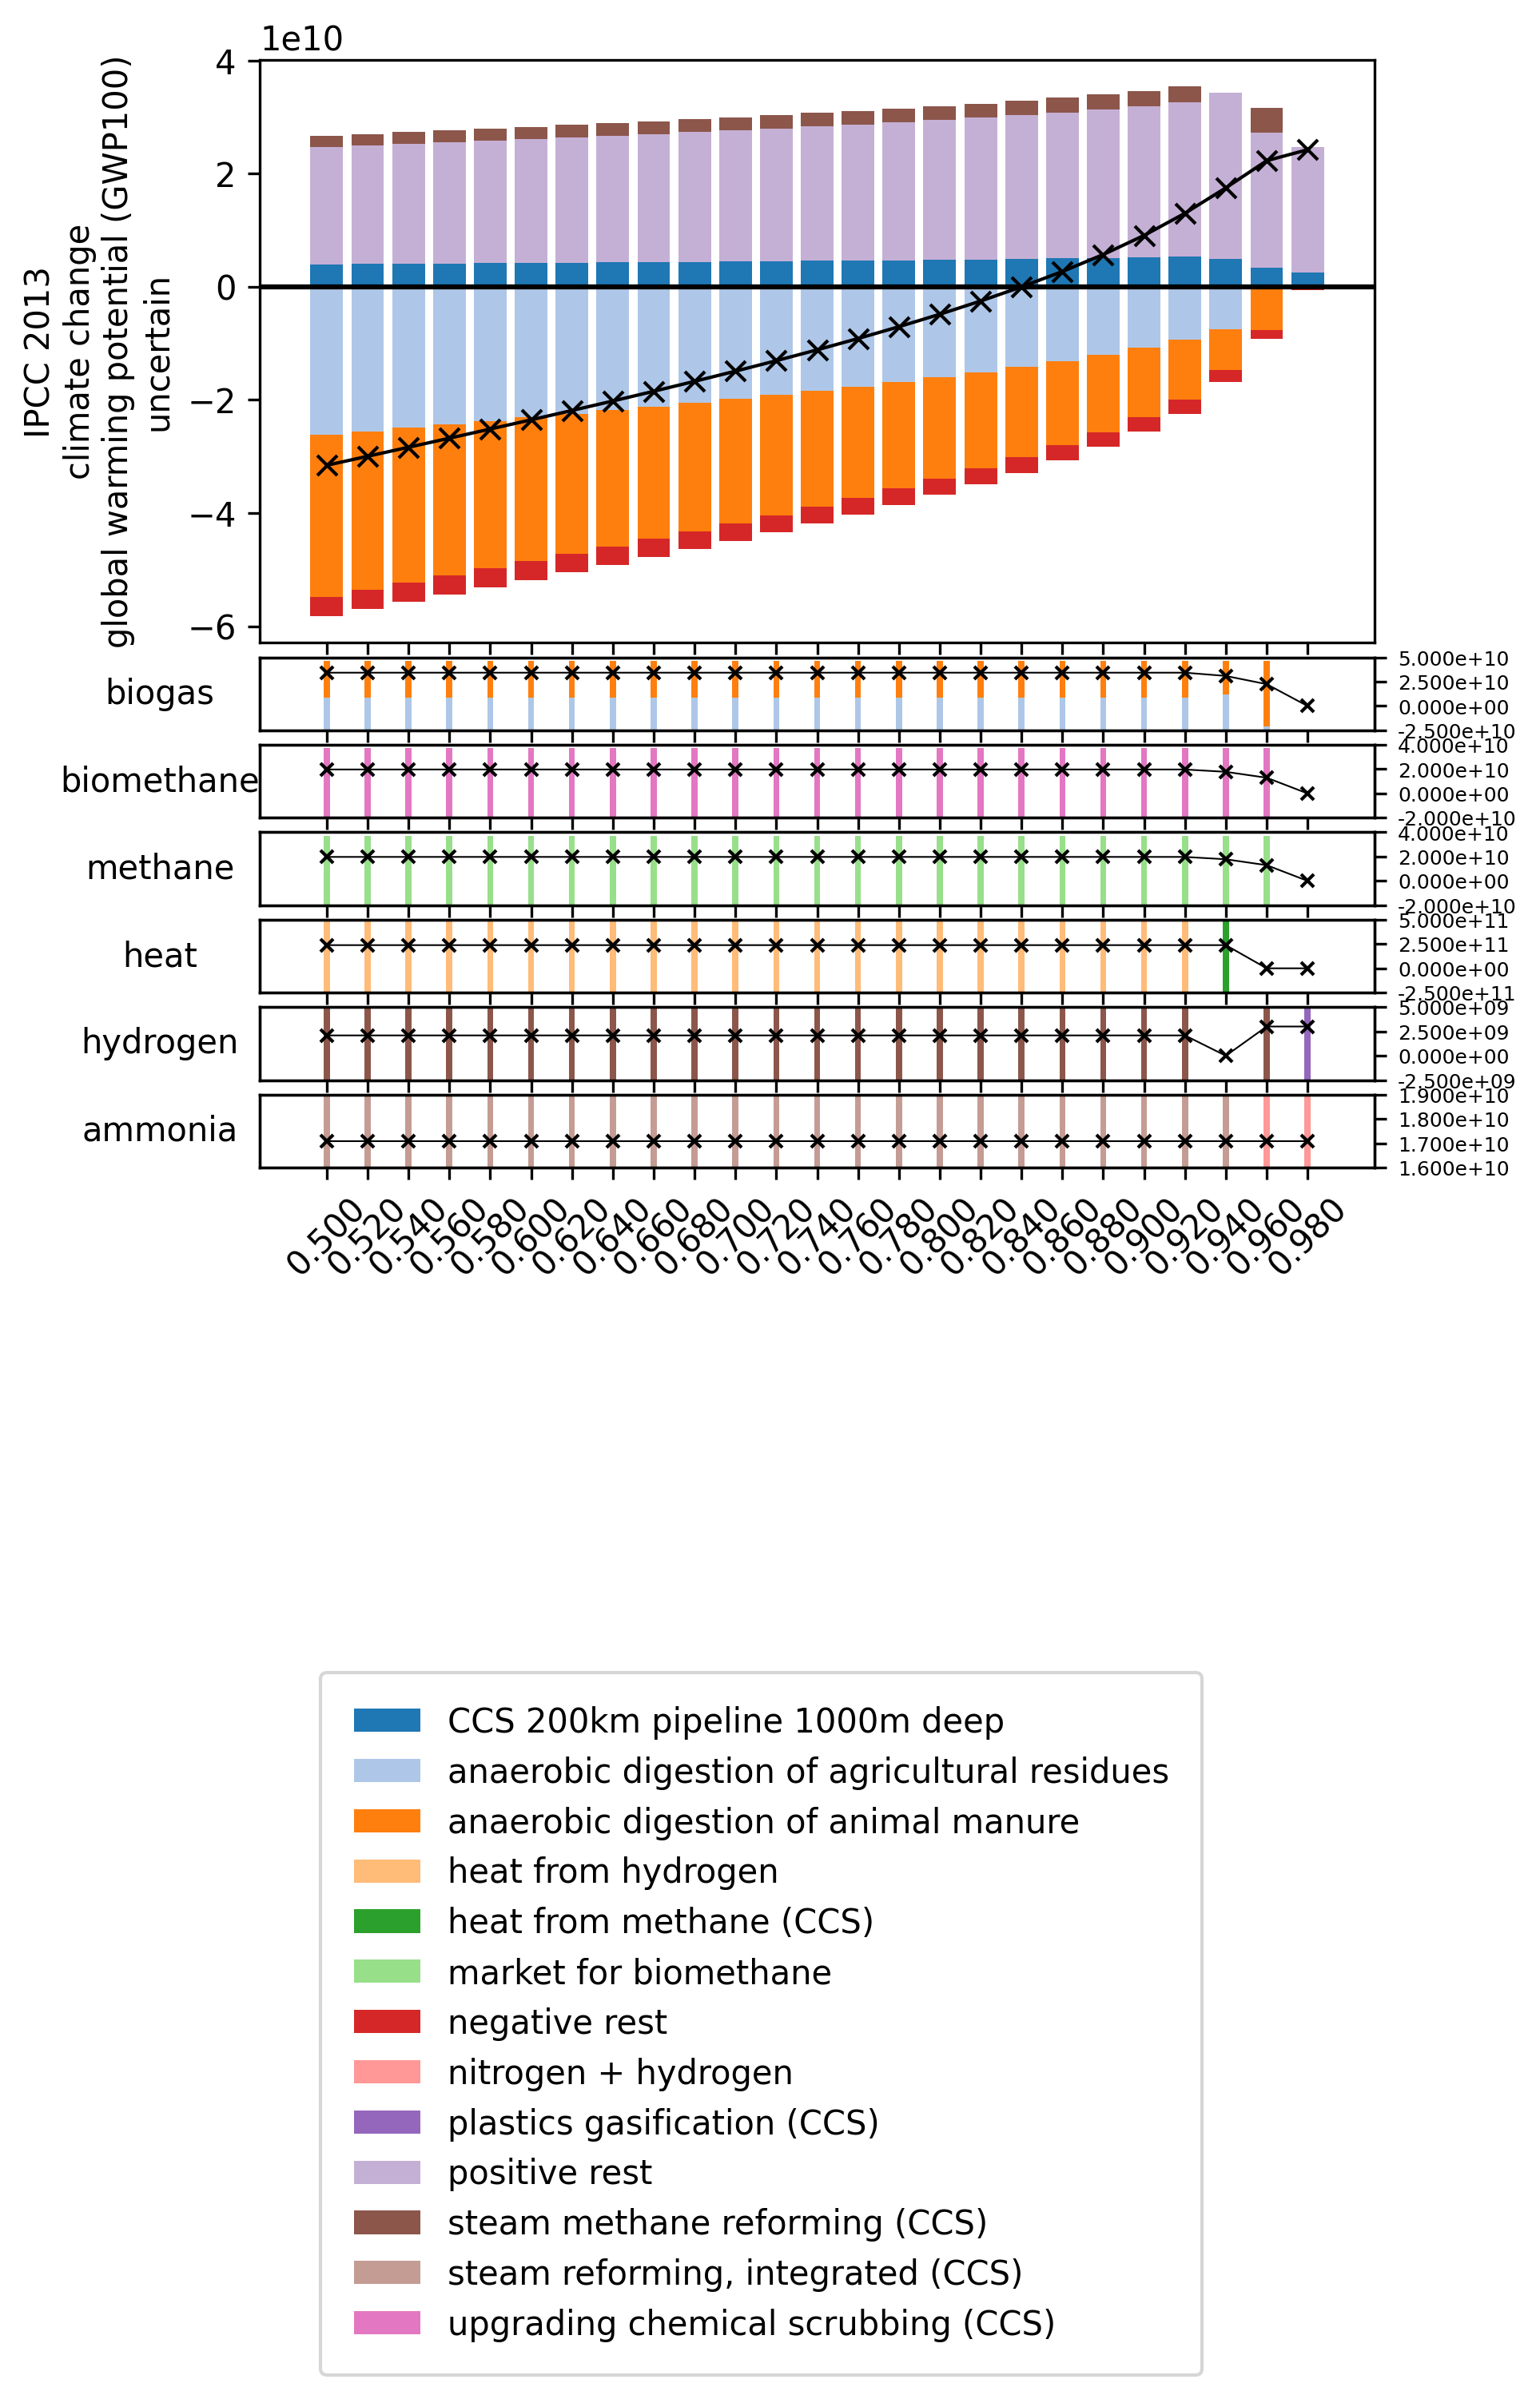

In [32]:
# "Old" internal visualization code
plots.plot_pareto_front(
    result_data_CC=results_CC_it0, 
    cutoff_value=0.05, 
    method="\n".join(METHOD.split("'")[1::2]), 
    process_map_metadata=pulpo_worker.lci_data['process_map_metadata'], 
    bbox_to_anchor=(0.45,-3.),
    cmap_name='tab20',
    group_act_by='process'
    )

### Iteration 1: Biomass Expert Judgement